In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [305]:
def create_ages(mu=50,sigma=13,num_samples=100,seed=42):
    np.random.seed(seed)
    ages = np.random.normal(loc=mu, scale=sigma, size=num_samples)
    ages = np.round(ages,decimals=0)
    return ages

In [306]:
sample = create_ages()
sample

array([56., 48., 58., 70., 47., 47., 71., 60., 44., 57., 44., 44., 53.,
       25., 28., 43., 37., 54., 38., 32., 69., 47., 51., 31., 43., 51.,
       35., 55., 42., 46., 42., 74., 50., 36., 61., 34., 53., 25., 33.,
       53., 60., 52., 48., 46., 31., 41., 44., 64., 54., 27., 54., 45.,
       41., 58., 63., 62., 39., 46., 54., 63., 44., 48., 36., 34., 61.,
       68., 49., 63., 55., 42., 55., 70., 50., 70., 16., 61., 51., 46.,
       51., 24., 47., 55., 69., 43., 39., 43., 62., 54., 43., 57., 51.,
       63., 41., 46., 45., 31., 54., 53., 50., 47.])

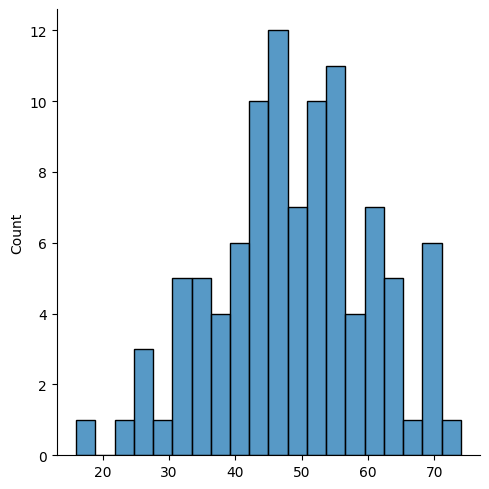

In [307]:
sns.displot(sample, bins=20)

<Axes: >

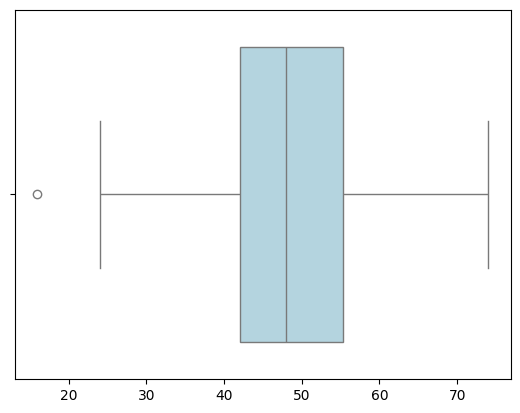

In [308]:
sns.boxplot(data=sample, orient="h", color="lightblue")

In [309]:
ser = pd.Series(sample)
ser.describe()

count    100.00000
mean      48.66000
std       11.82039
min       16.00000
25%       42.00000
50%       48.00000
75%       55.25000
max       74.00000
dtype: float64

In [310]:
IQR = 55.25 - 42.0
lower_bound = 42.0 - 1.5 * IQR
lower_bound

22.125

In [311]:
ser[ser>lower_bound]

0     56.0
1     48.0
2     58.0
3     70.0
4     47.0
      ... 
95    31.0
96    54.0
97    53.0
98    50.0
99    47.0
Length: 99, dtype: float64

<Axes: >

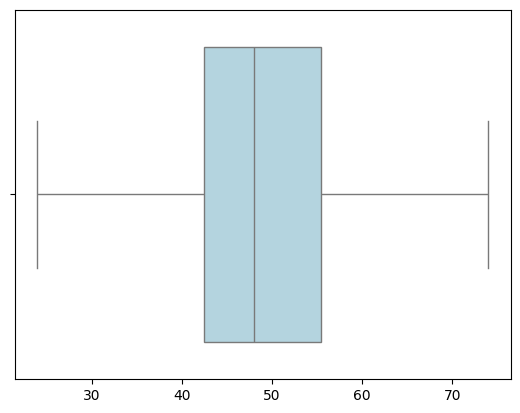

In [312]:
sns.boxplot(data=ser[ser>lower_bound], orient="h", color="lightblue")

In [313]:
# q75,q25 =np.percentile(sample, [75])
# iqr = q75 - q25
# q25 - 1.5*iqr

In [314]:
df = pd.read_csv("Ames_Housing_data.csv")
df.head()
df.corr(numeric_only=True)["SalePrice"]


Id              0.015925
MSSubClass      0.001755
LotFrontage     0.010618
LotArea         0.033473
OverallQual     0.405697
OverallCond    -0.041949
YearBuilt       0.147057
YearRemodAdd    0.023584
TotalBsmtSF     0.188434
GrLivArea       0.496815
FullBath       -0.004084
HalfBath        0.040708
BedroomAbvGr   -0.002049
TotRmsAbvGrd    0.004885
GarageCars      0.179889
SalePrice       1.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

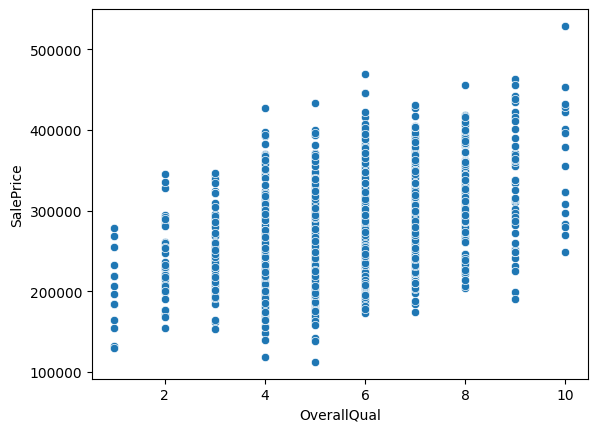

In [315]:
sns.scatterplot(x="OverallQual",y="SalePrice",data=df)

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

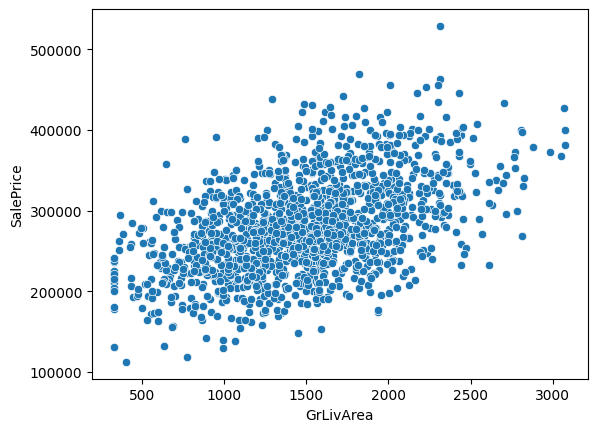

In [316]:
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")

In [317]:
df[(df['OverallQual']>8) & (df['SalePrice']>450000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,GarageCars,SalePrice
115,116,80,RL,48,12208,Somerst,10,6,1999,1999,1085,2313,1,0,3,7,4,529211
188,189,180,RL,79,7830,NWAmes,9,5,1918,1970,1047,2317,2,0,2,5,2,463562
1007,1008,80,RM,51,9931,StoneBr,9,3,1929,1967,1627,2013,2,0,3,8,2,455967
1372,1373,20,RM,50,13655,SawyerW,10,6,1980,1980,1908,2230,1,0,2,7,1,453273


In [318]:
df[(df["GrLivArea"]>2000) & (df["SalePrice"]<400000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,GarageCars,SalePrice
0,1,70,RL,81,7497,OldTown,7,5,1995,1995,717,2432,2,0,2,7,3,367413
23,24,180,RL,131,12487,NWAmes,2,2,1982,1982,473,2041,1,1,3,11,2,261022
26,27,180,RL,66,16236,Edwards,6,8,1924,1977,1264,2395,2,0,4,7,2,331297
27,28,50,RL,78,11498,OldTown,2,6,1959,1999,1532,2365,2,0,3,9,2,295287
31,32,60,RL,96,8414,NPkVill,8,4,1960,2008,1539,2378,2,0,3,6,3,384788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,1436,190,RL,91,12873,SWISU,8,9,1933,1984,833,2320,2,0,2,9,2,386521
1446,1447,40,RL,92,10006,Veenker,6,6,1887,1987,504,2197,1,1,2,8,2,301961
1448,1449,80,RM,68,11518,ClearCr,4,9,1895,2000,1311,2258,1,0,3,6,1,253127
1450,1451,45,RL,57,1643,OldTown,6,5,1985,1991,1504,2035,1,1,3,8,1,371413


In [319]:
with open('./DataDocumentation.txt','r') as f :
    print(f.read())


MS SubClass (Nominal): Identifies the type of dwelling involved in the sale.	

       020	1-STORY 1946 & NEWER ALL STYLES
       030	1-STORY 1945 & OLDER
       040	1-STORY W/FINISHED ATTIC ALL AGES
       045	1-1/2 STORY - UNFINISHED ALL AGES
       050	1-1/2 STORY FINISHED ALL AGES
       060	2-STORY 1946 & NEWER
       070	2-STORY 1945 & OLDER
       075	2-1/2 STORY ALL AGES
       080	SPLIT OR MULTI-LEVEL
       085	SPLIT FOYER
       090	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MS Zoning (Nominal): Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low 

In [320]:
df = pd.read_csv("./Ames_outliers_removed.csv")
df.head()
# df.groupby('Garage Type')['Garage Type'].count()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [321]:
df=df.drop('PID',axis=1)


In [322]:
len(df.columns)


80

In [323]:
df.isnull().sum()

MS SubClass         0
MS Zoning           0
Lot Frontage      490
Lot Area            0
Street              0
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 80, dtype: int64

In [324]:
100*df.isnull().sum()/len(df)

MS SubClass        0.00000
MS Zoning          0.00000
Lot Frontage      16.74069
Lot Area           0.00000
Street             0.00000
                    ...   
Mo Sold            0.00000
Yr Sold            0.00000
Sale Type          0.00000
Sale Condition     0.00000
SalePrice          0.00000
Length: 80, dtype: float64

In [325]:
def percent_missing(df):
    percent_nan=100*df.isnull().sum()/len(df)
    percent_nan = percent_nan[percent_nan > 0].sort_values()
    return percent_nan
# percent_missing(df)

In [326]:
percent_nan=percent_missing(df)
percent_nan

Total Bsmt SF      0.034165
Bsmt Unf SF        0.034165
BsmtFin SF 2       0.034165
Electrical         0.034165
BsmtFin SF 1       0.034165
Garage Area        0.034165
Garage Cars        0.034165
Bsmt Full Bath     0.068329
Bsmt Half Bath     0.068329
Mas Vnr Area       0.785787
Bsmt Qual          2.733174
Bsmt Cond          2.733174
BsmtFin Type 1     2.733174
BsmtFin Type 2     2.767339
Bsmt Exposure      2.835668
Garage Type        5.363854
Garage Qual        5.432183
Garage Finish      5.432183
Garage Cond        5.432183
Garage Yr Blt      5.432183
Lot Frontage      16.740690
Fireplace Qu      48.582166
Mas Vnr Type      60.642296
Fence             80.457807
Alley             93.235395
Misc Feature      96.412709
Pool QC           99.590024
dtype: float64

(0.0, 1.0)

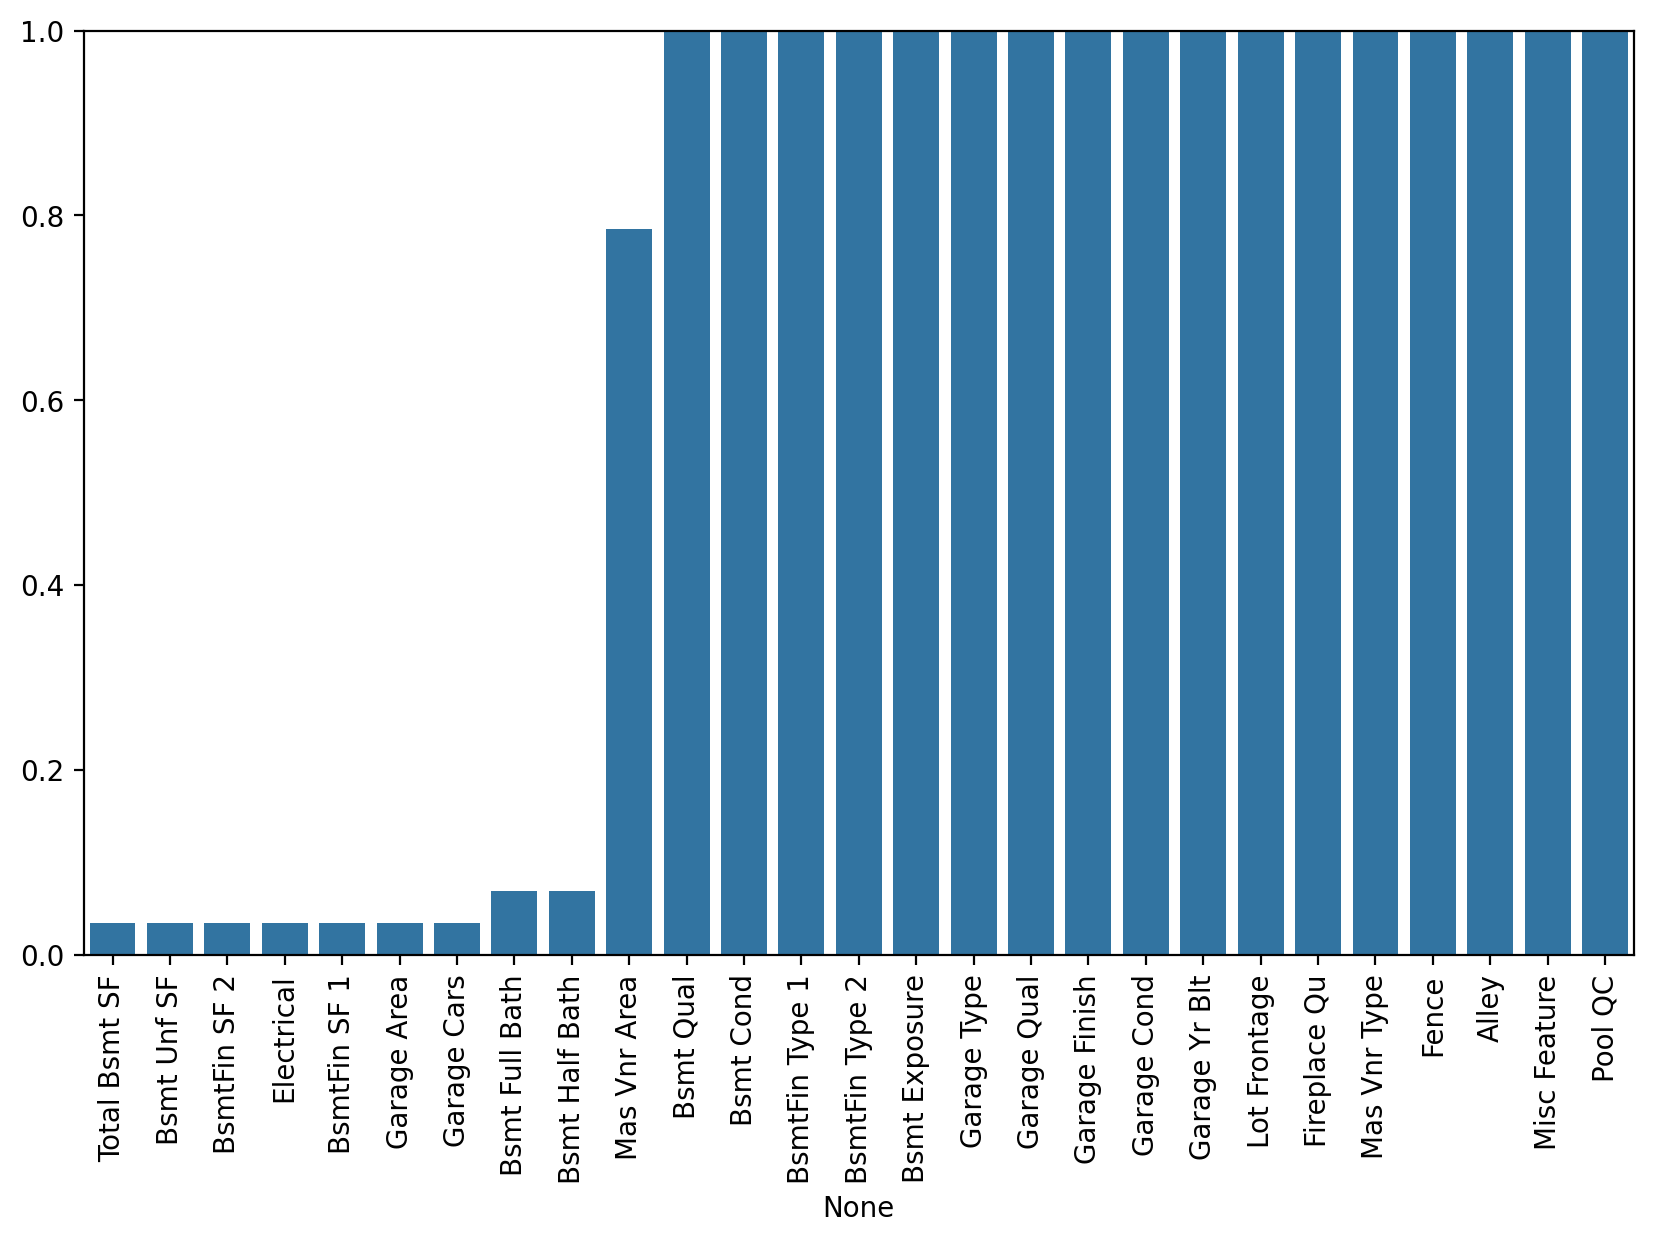

In [327]:
plt.figure(figsize=(10,6),dpi=200)
sns.barplot(x=percent_missing(df).index, y=percent_missing(df).values)
plt.xticks(rotation=90)
plt.ylim(0,1)

In [328]:
percent_nan[percent_nan< 1]

Total Bsmt SF     0.034165
Bsmt Unf SF       0.034165
BsmtFin SF 2      0.034165
Electrical        0.034165
BsmtFin SF 1      0.034165
Garage Area       0.034165
Garage Cars       0.034165
Bsmt Full Bath    0.068329
Bsmt Half Bath    0.068329
Mas Vnr Area      0.785787
dtype: float64

In [329]:
100/len(df)

0.0341646737273659

In [330]:
df[df['Electrical'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1576,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [331]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [332]:
df = df.dropna(axis=0,subset=['Electrical','Garage Cars'])
percent_nan=percent_missing(df)
percent_nan[percent_nan< 1]

Total Bsmt SF     0.034188
Bsmt Unf SF       0.034188
BsmtFin SF 2      0.034188
BsmtFin SF 1      0.034188
Bsmt Full Bath    0.068376
Bsmt Half Bath    0.068376
Mas Vnr Area      0.786325
dtype: float64

(0.0, 1.0)

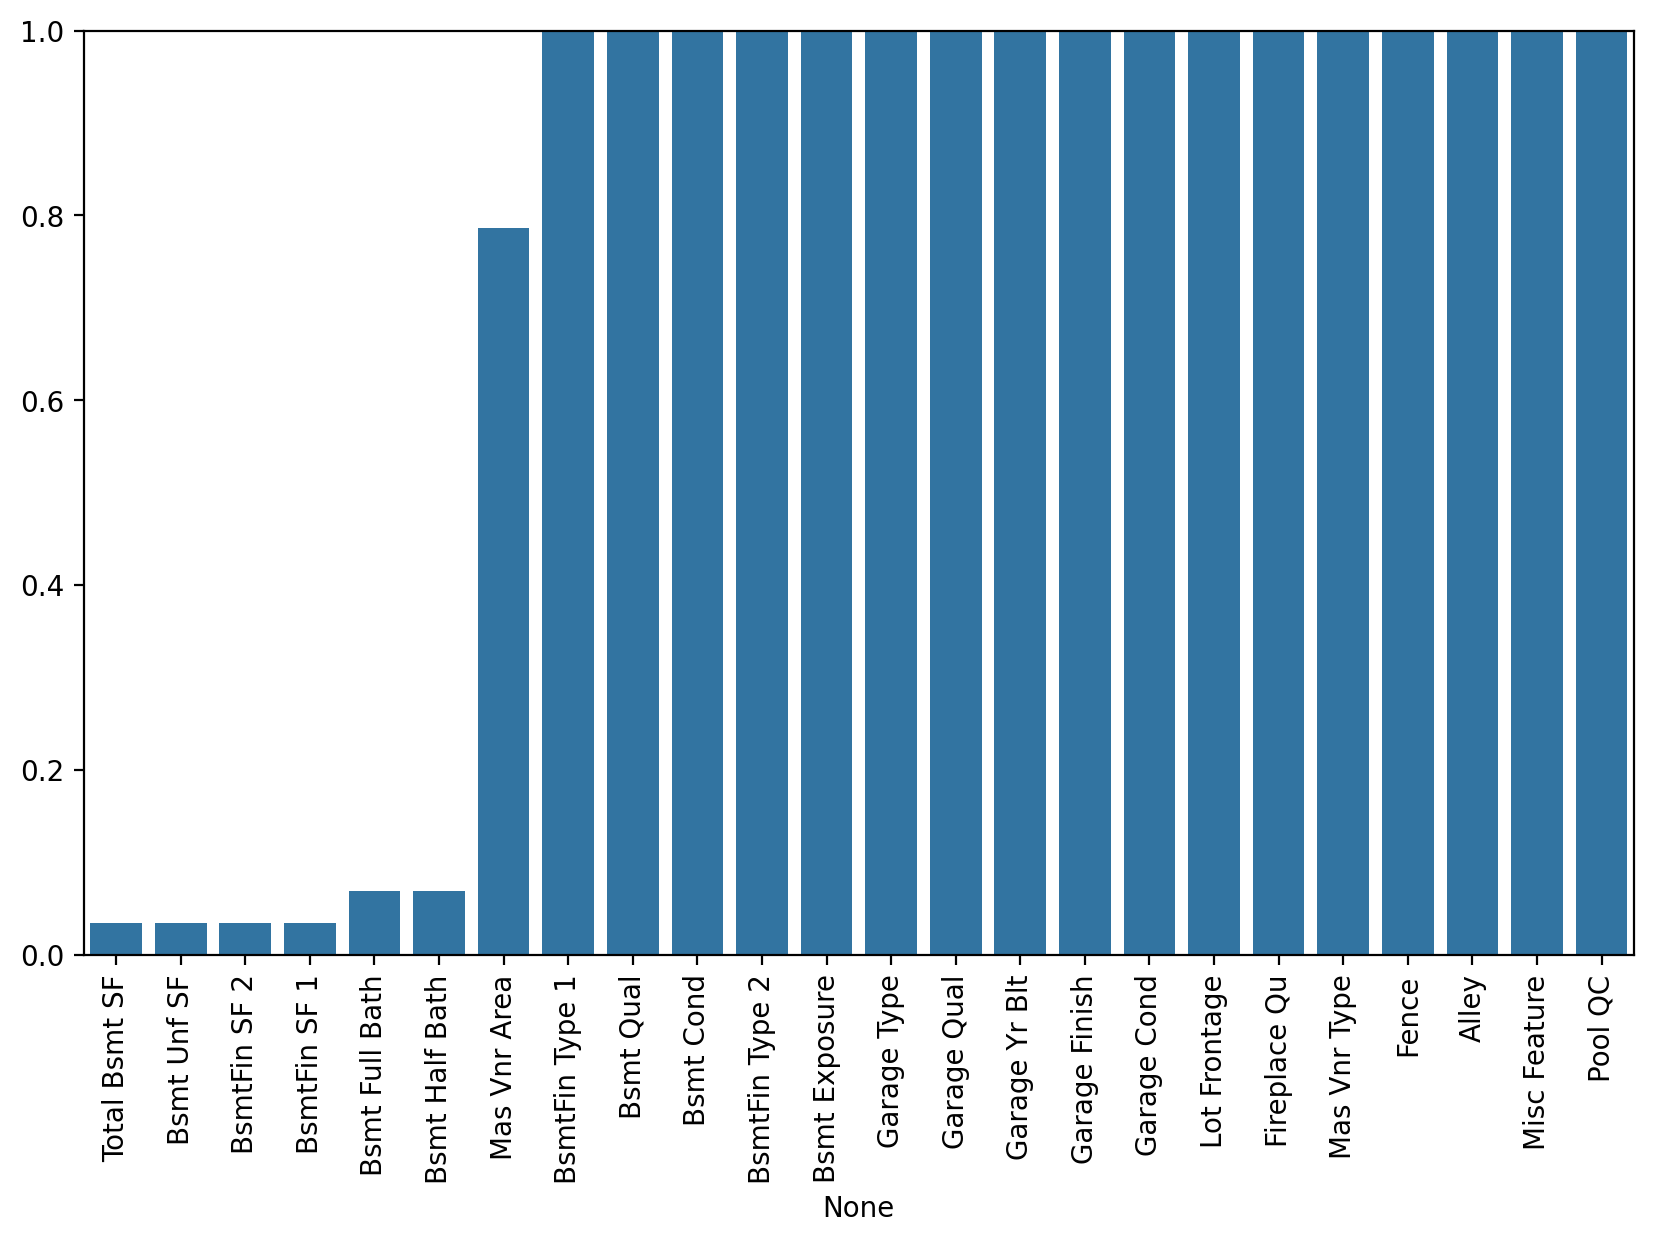

In [333]:
plt.figure(figsize=(10,6),dpi=200)
sns.barplot(x=percent_missing(df).index, y=percent_missing(df).values)
plt.xticks(rotation=90)
plt.ylim(0,1)

In [334]:
df.groupby('Garage Type')['Garage Type'].count()

Garage Type
2Types       23
Attchd     1729
Basment      36
BuiltIn     184
CarPort      15
Detchd      781
Name: Garage Type, dtype: int64

In [335]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [336]:
df[df['Bsmt Full Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [337]:
# BSMT NUMERIC COLUMNS
bsmt_numeric_cols = [col for col in df.columns if col.startswith("Bsmt") and df[col].dtype in ['int64','float64']]
bsmt_numeric_cols
# bsmt STRING COLUMNS
bsmt_string_cols = [col for col in df.columns if col.startswith("Bsmt") and df[col].dtype == 'object']
bsmt_string_cols

['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']

In [338]:
# BSMT NUMERIC COLUMNS
bsmt_num_cols = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Bsmt Unf SF', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Total Bsmt SF']
df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)
# bsmt STRING COLUMNS
bsmt_str_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
df[bsmt_str_cols] = df[bsmt_str_cols].fillna("None")



(0.0, 1.0)

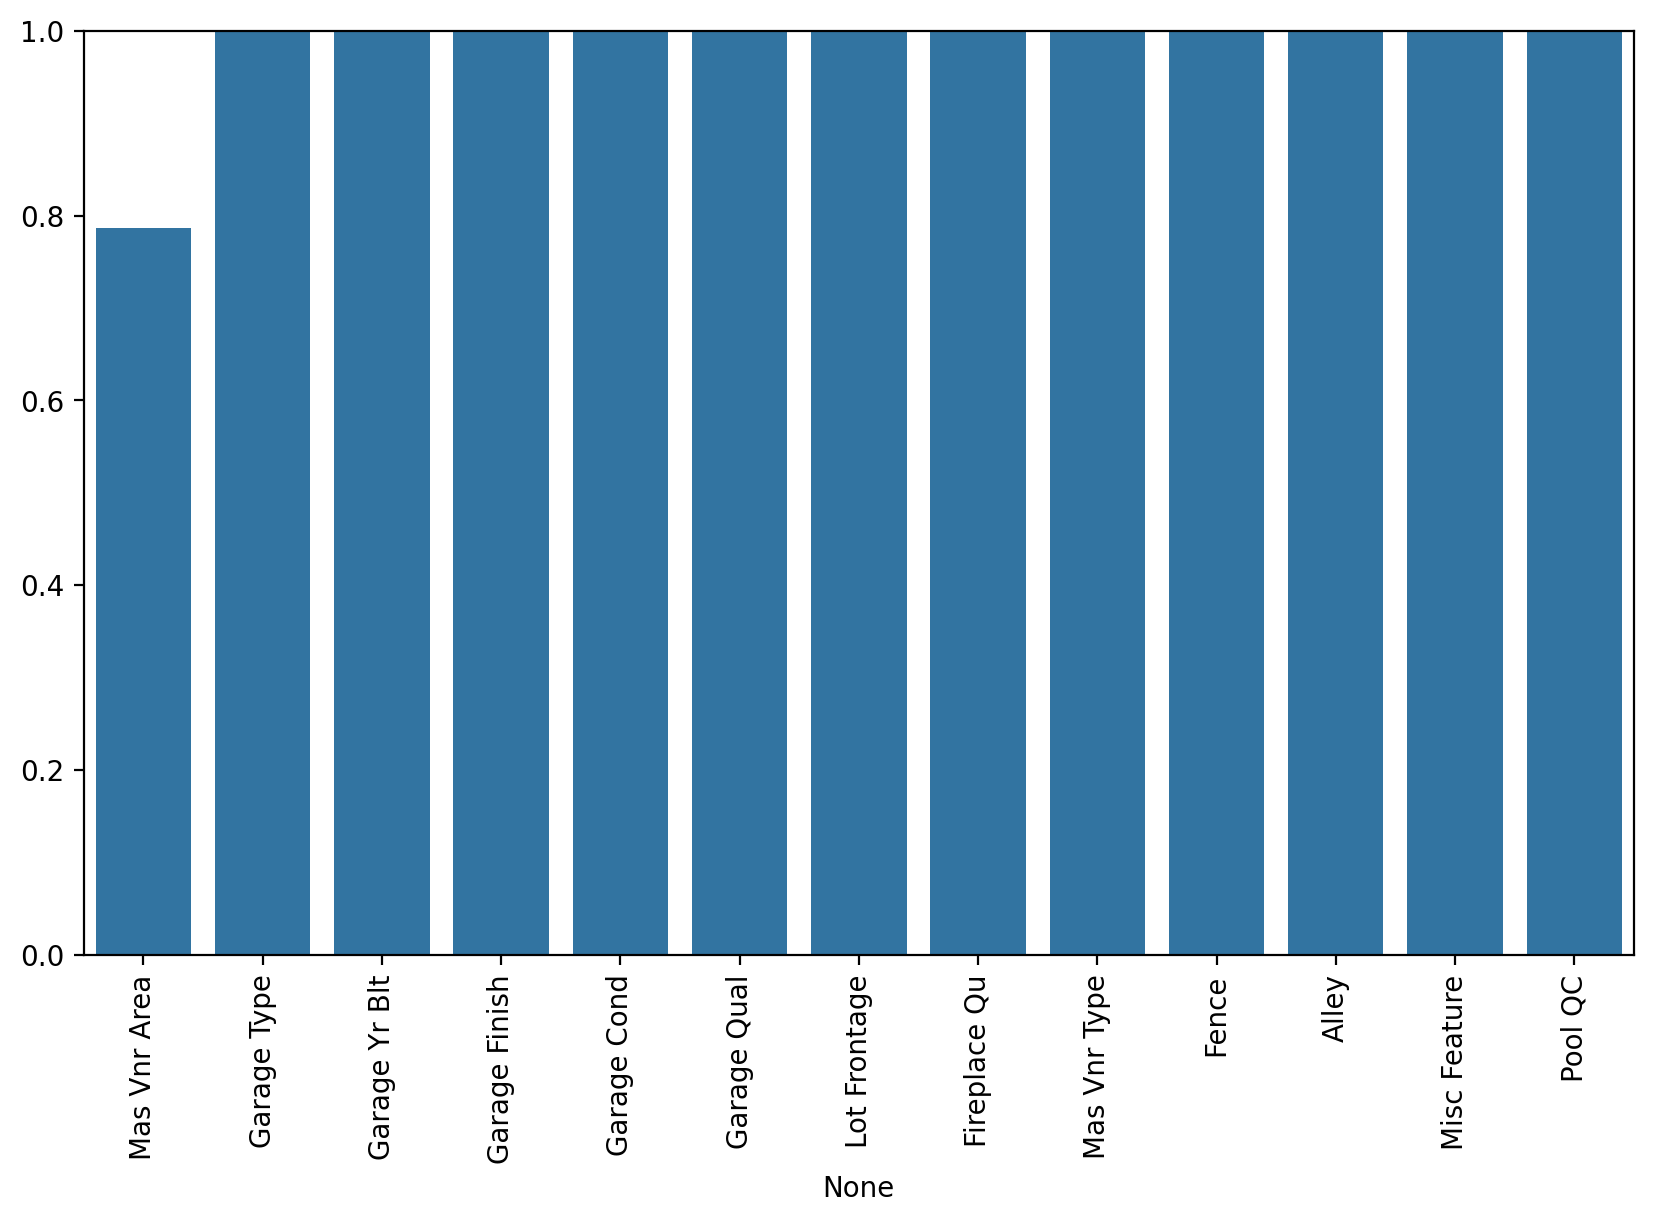

In [339]:
plt.figure(figsize=(10,6),dpi=200)
sns.barplot(x=percent_missing(df).index, y=percent_missing(df).values)
plt.xticks(rotation=90)
plt.ylim(0,1)

In [340]:
df

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2923,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2924,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2925,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [341]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna("None")
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)
percent_nan=percent_missing(df)

(0.0, 1.0)

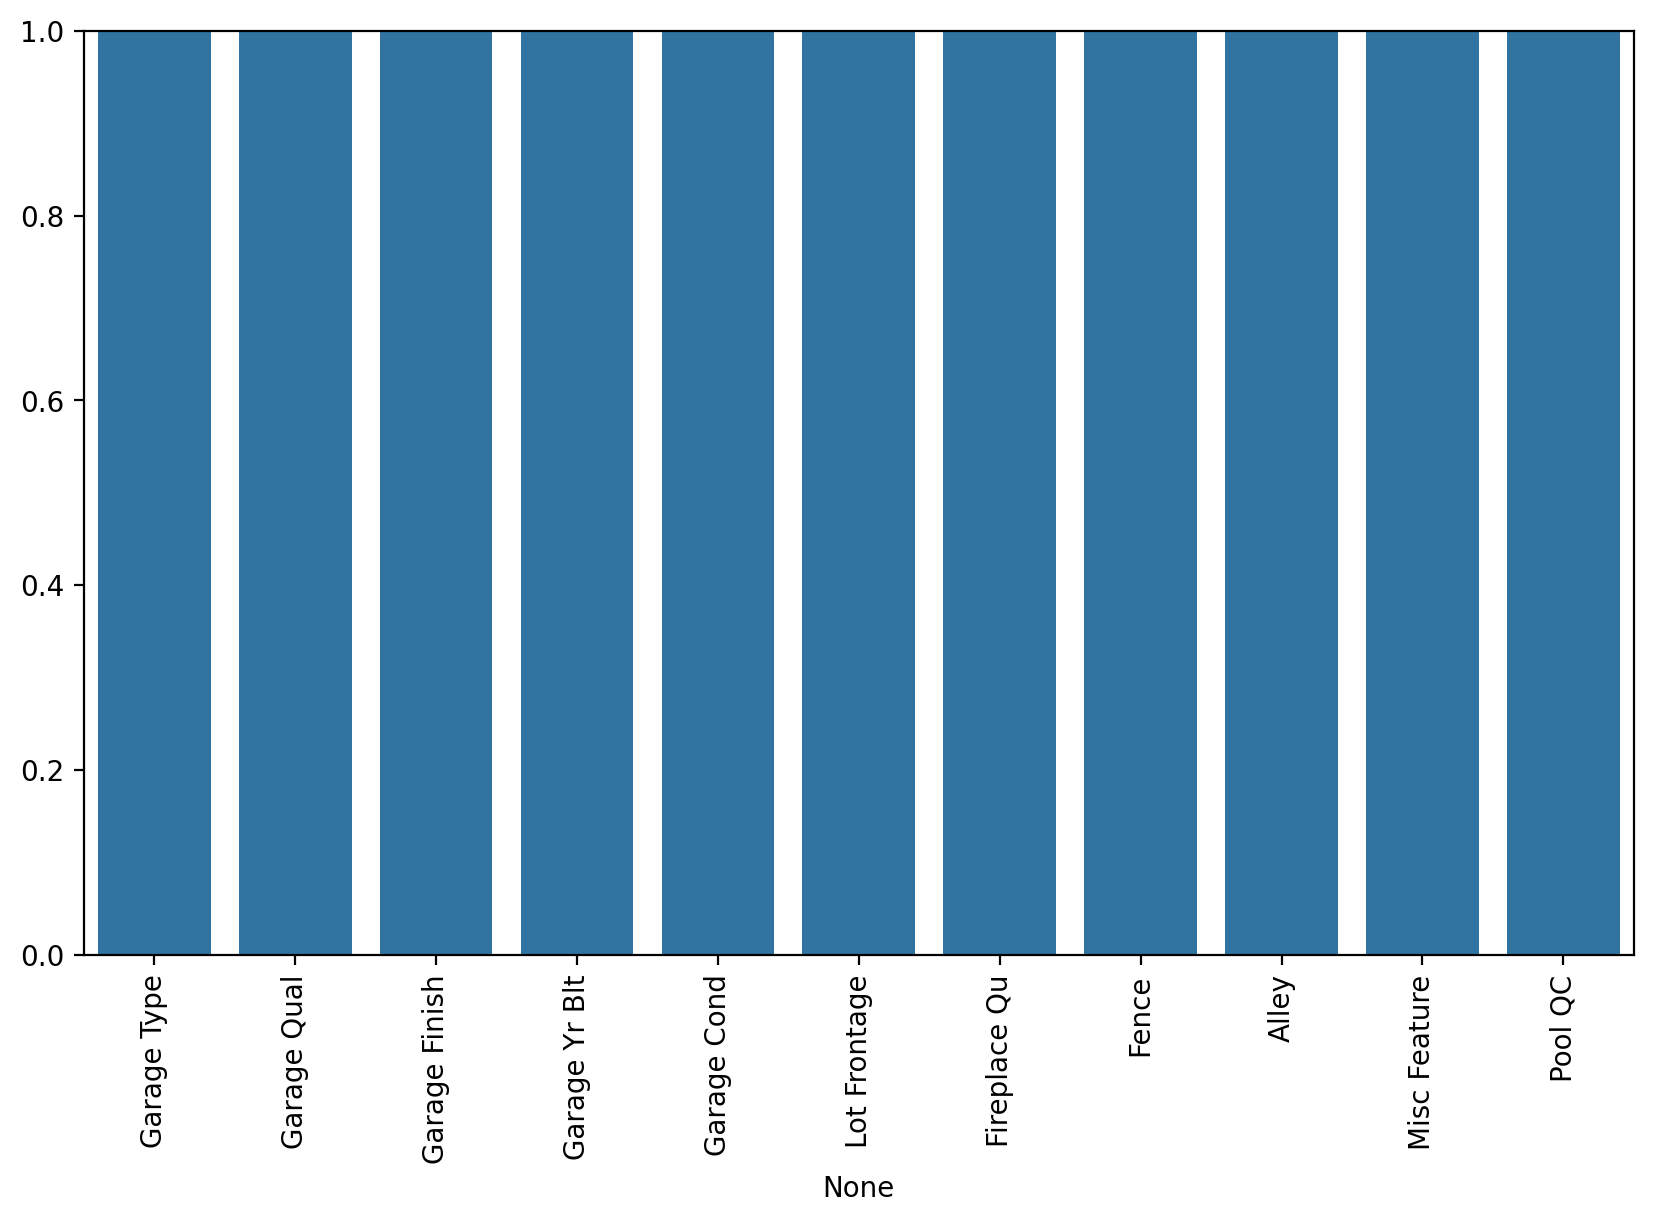

In [342]:
plt.figure(figsize=(10,6),dpi=200)
sns.barplot(x=percent_missing(df).index, y=percent_missing(df).values)
plt.xticks(rotation=90)
plt.ylim(0,1)

In [343]:
gar_str_cols = ['Garage Type','Garage Finish','Garage Qual','Garage Cond']

In [344]:
df.loc[:, gar_str_cols] = df[gar_str_cols].fillna('None')

In [345]:
percent_nan=percent_missing(df)

(0.0, 1.0)

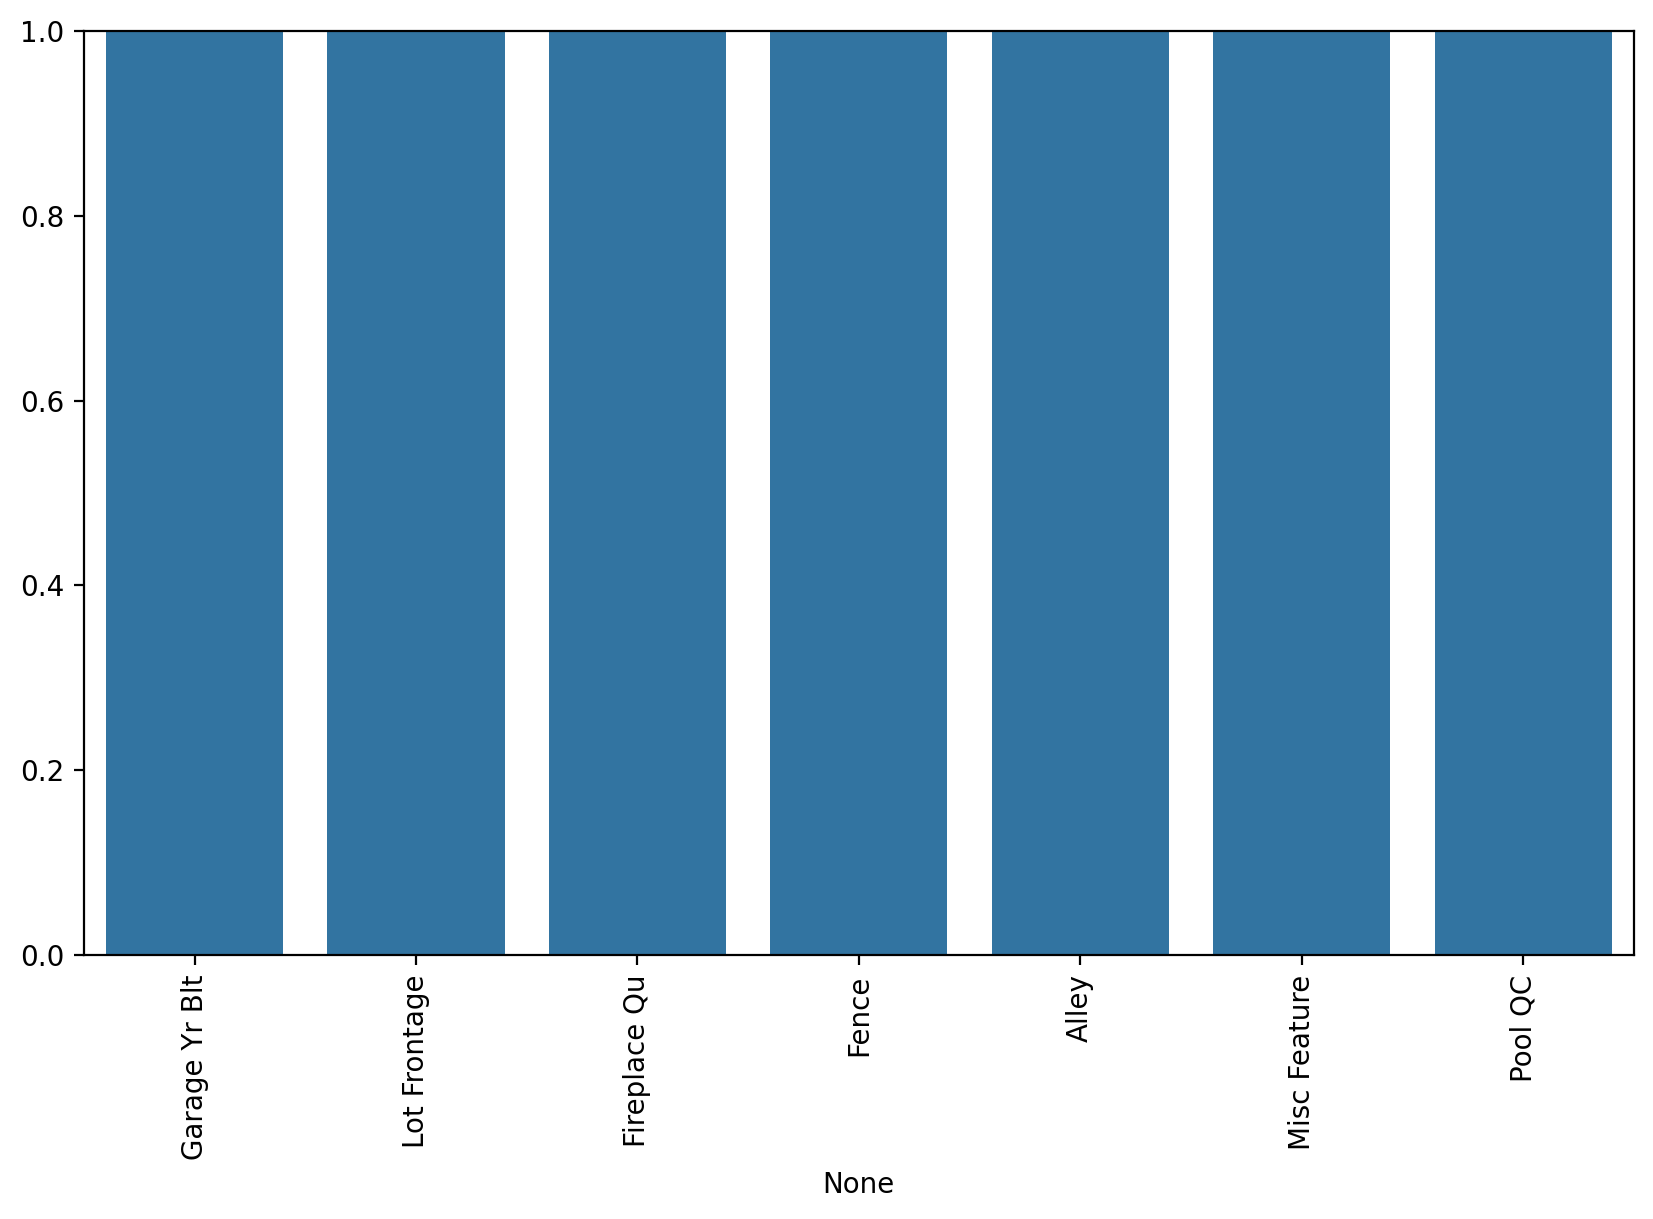

In [346]:
plt.figure(figsize=(10,6),dpi=200)
sns.barplot(x=percent_missing(df).index, y=percent_missing(df).values)
plt.xticks(rotation=90)
plt.ylim(0,1)

In [347]:
df.loc['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

(0.0, 1.0)

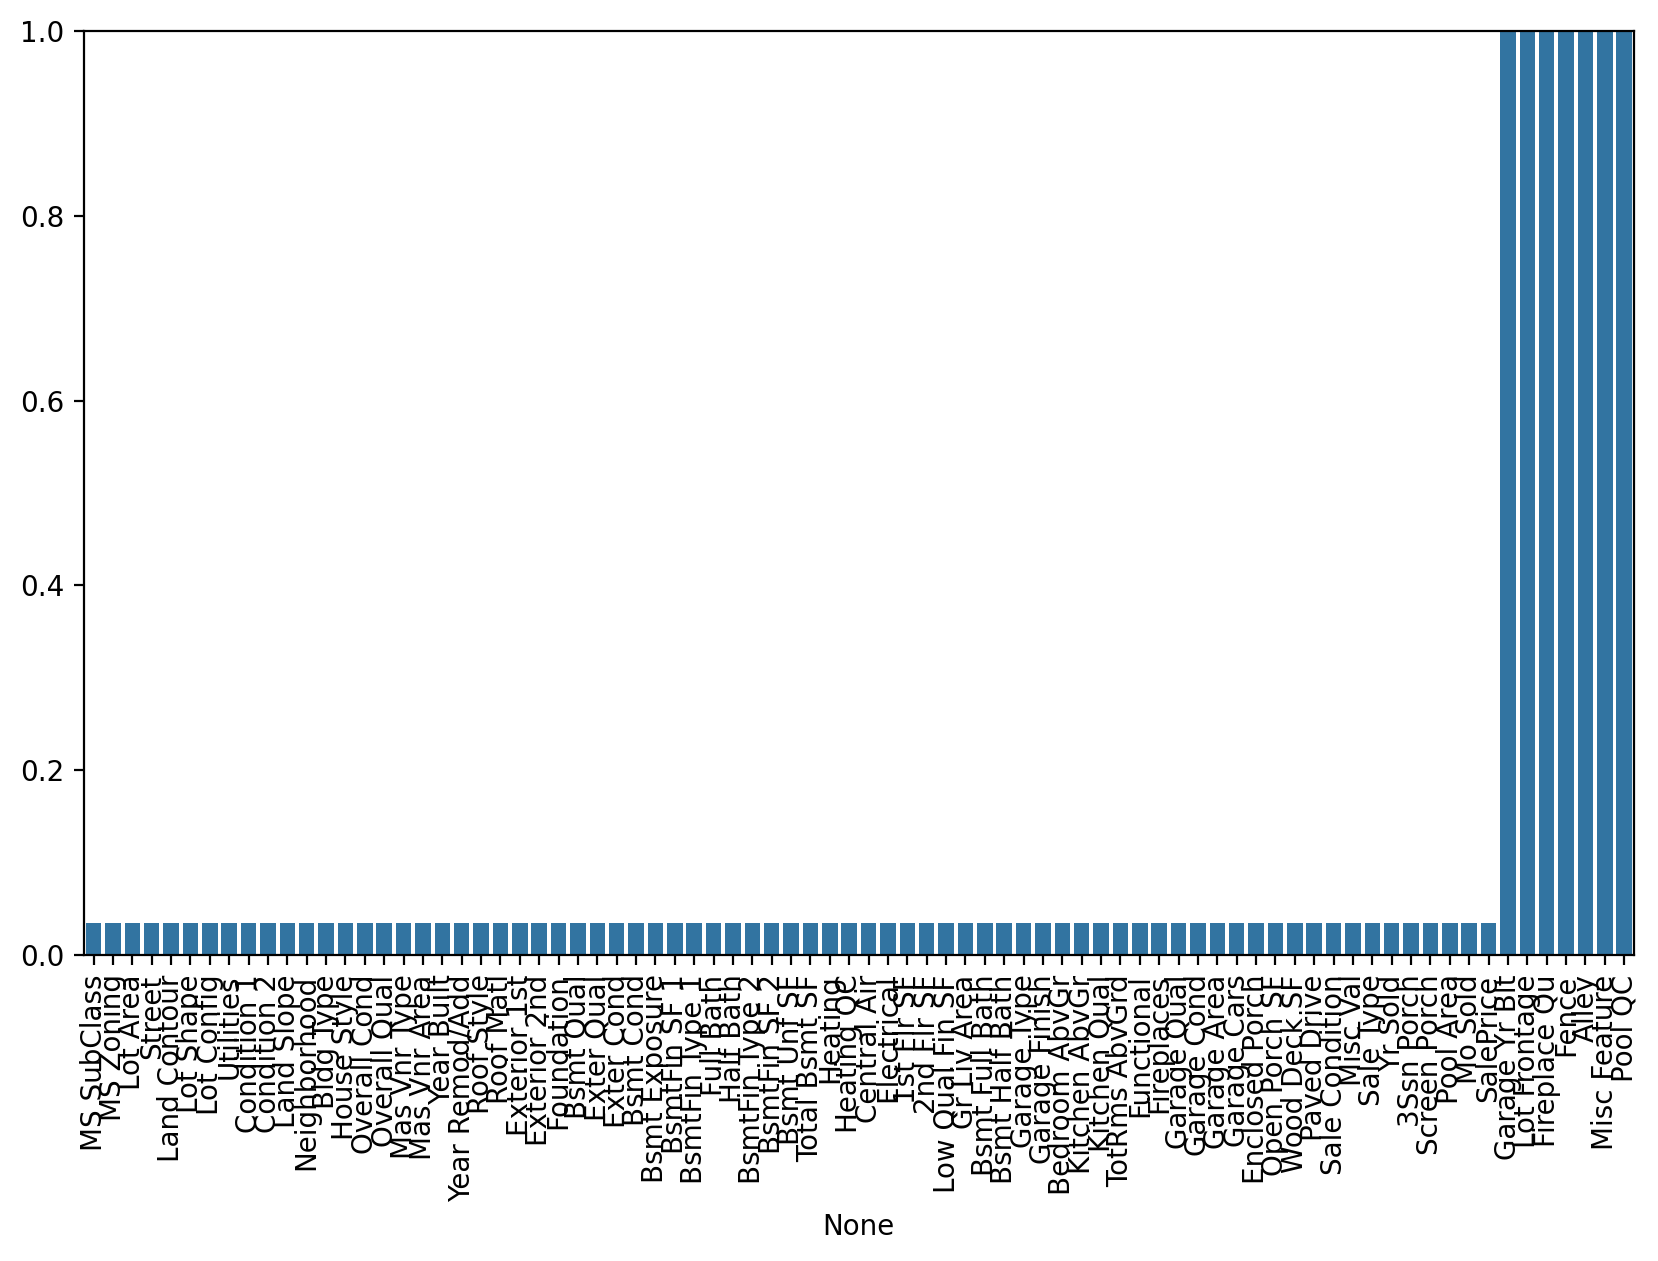

In [348]:
plt.figure(figsize=(10,6),dpi=200)
sns.barplot(x=percent_missing(df).index, y=percent_missing(df).values)
plt.xticks(rotation=90)
plt.ylim(0,1)

In [349]:
# First, see what columns you have
print(df.columns.tolist())

# Then drop rows with NaN in only the columns that exist
cols_to_check = ['Pool QC', 'Fence', 'Misc Feature', 'Alley']
cols_to_check = [col for col in cols_to_check if col in df.columns]
df = df.dropna(subset=cols_to_check)

['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF', 'Open Porch

(0.0, 1.0)

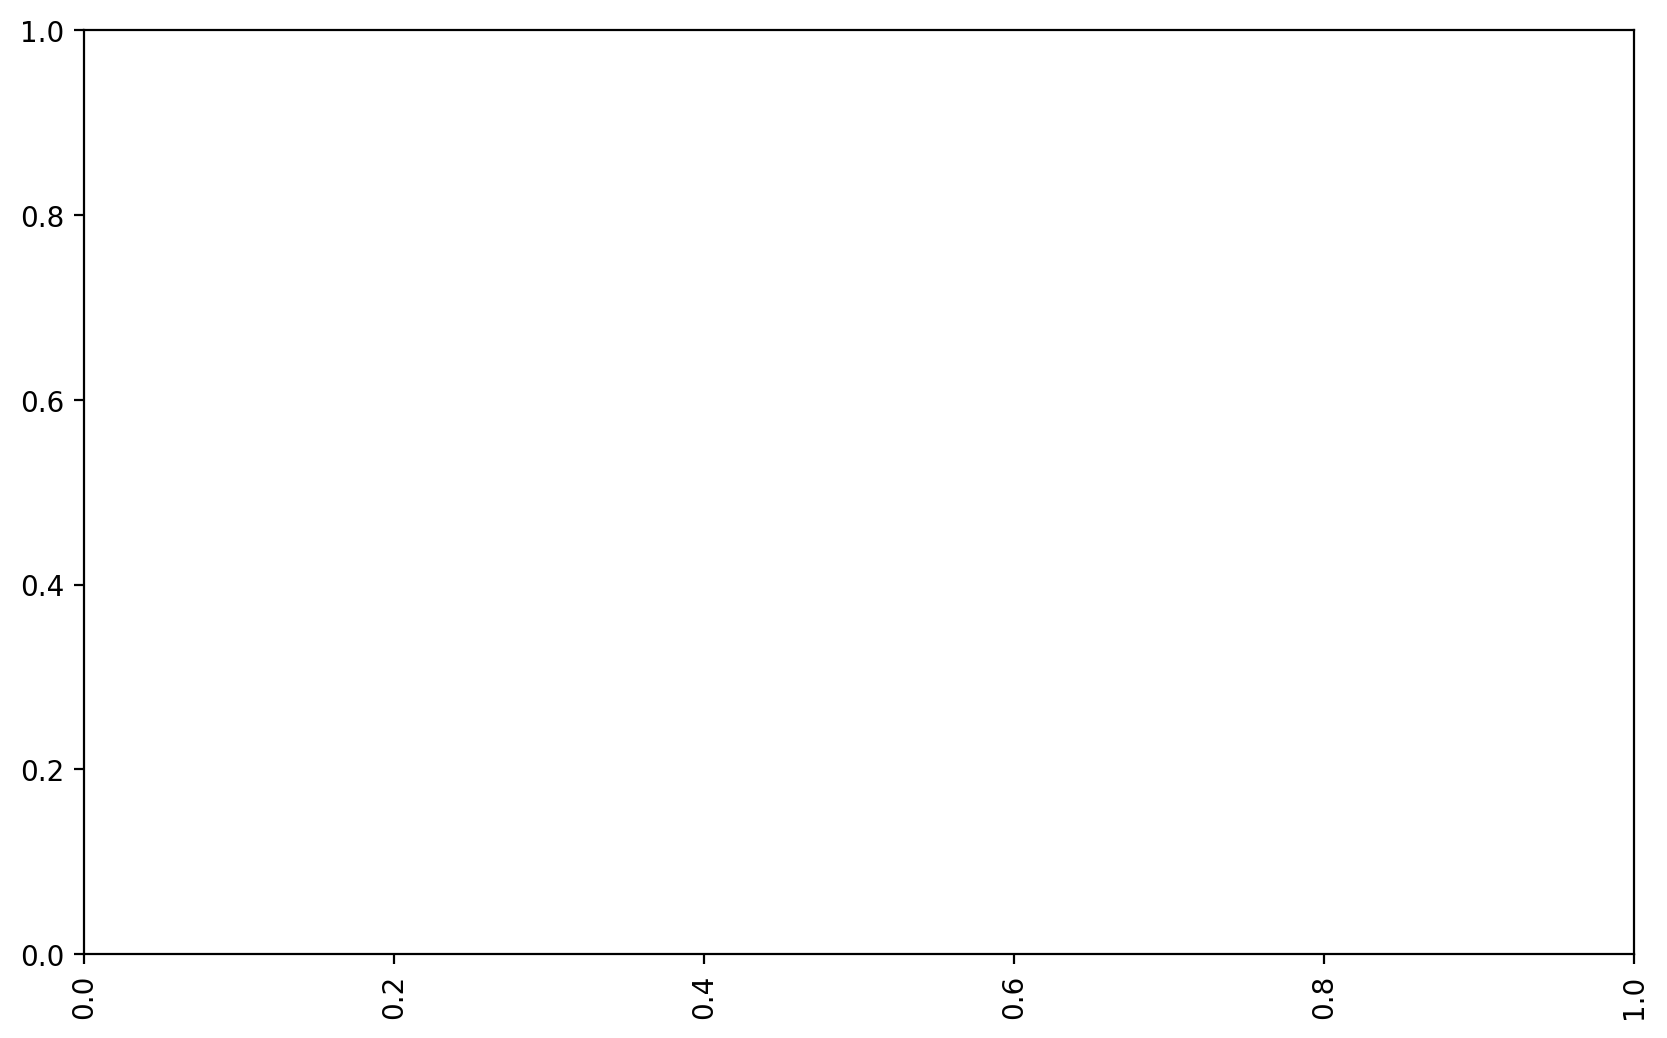

In [350]:
plt.figure(figsize=(10,6),dpi=200)
sns.barplot(x=percent_missing(df).index, y=percent_missing(df).values)
plt.xticks(rotation=90)
plt.ylim(0,1)


In [351]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


In [352]:
df = pd.read_csv("./Ames_NO_Missing_Data.csv")
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2010,WD,Normal,189900


In [353]:
df['MS SubClass'] = df['MS SubClass'].apply(str)

In [354]:
direction = pd.Series(['up','down','up','down'])
direction

0      up
1    down
2      up
3    down
dtype: object

In [355]:
pd.get_dummies(direction,drop_first=True)

,up
0,True
1,False
2,True
3,False


In [356]:
df.select_dtypes(include='object')

,MS SubClass,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
0,20,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,TA,Typ,Gd,Attchd,Fin,TA,TA,P,WD,Normal
1,20,RH,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,...,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
2,20,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Gd,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
3,20,RL,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
4,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,80,RL,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,...,TA,Typ,NaN,Detchd,Unf,TA,TA,Y,WD,Normal
2921,20,RL,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,...,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
2922,85,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,TA,Typ,NaN,NaN,NaN,NaN,NaN,Y,WD,Normal
2923,20,RL,Pave,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [357]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2925 non-null   object 
 1   MS Zoning        2925 non-null   object 
 2   Lot Frontage     2925 non-null   float64
 3   Lot Area         2925 non-null   int64  
 4   Street           2925 non-null   object 
 5   Lot Shape        2925 non-null   object 
 6   Land Contour     2925 non-null   object 
 7   Utilities        2925 non-null   object 
 8   Lot Config       2925 non-null   object 
 9   Land Slope       2925 non-null   object 
 10  Neighborhood     2925 non-null   object 
 11  Condition 1      2925 non-null   object 
 12  Condition 2      2925 non-null   object 
 13  Bldg Type        2925 non-null   object 
 14  House Style      2925 non-null   object 
 15  Overall Qual     2925 non-null   int64  
 16  Overall Cond     2925 non-null   int64  
 17  Year Built    

In [358]:
my_object= df.select_dtypes(include='object')

In [359]:
my_numeric = df.select_dtypes(exclude='object')

In [361]:
my_numeric

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,141.000000,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,210,62,0,0,0,0,0,5,2010,215000
1,80.000000,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,140,0,0,0,120,0,0,6,2010,105000
2,81.000000,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,393,36,0,0,0,0,12500,6,2010,172000
3,93.000000,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,0,0,0,0,0,0,0,4,2010,244000
4,74.000000,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,212,34,0,0,0,0,0,3,2010,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,37.000000,7937,6,6,1984,1984,0.0,819.0,0.0,184.0,...,120,0,0,0,0,0,0,3,2006,142500
2921,75.144444,8885,5,5,1983,1983,0.0,301.0,324.0,239.0,...,164,0,0,0,0,0,0,6,2006,131000
2922,62.000000,10441,5,5,1992,1992,0.0,337.0,0.0,575.0,...,80,32,0,0,0,0,700,7,2006,132000
2923,77.000000,10010,5,5,1974,1975,0.0,1071.0,123.0,195.0,...,240,38,0,0,0,0,0,4,2006,170000


In [362]:
object_dummies=pd.get_dummies(my_object,drop_first=True)
object_dummies


,MS SubClass_150,MS SubClass_160,MS SubClass_180,MS SubClass_190,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2921,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2922,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2923,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [363]:
final_df = pd.concat([my_numeric,object_dummies],axis=1)
final_df

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,141.000000,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,False,False,False,False,True,False,False,False,True,False
1,80.000000,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,False,False,False,False,True,False,False,False,True,False
2,81.000000,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,False,False,False,False,True,False,False,False,True,False
3,93.000000,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,False,False,False,False,True,False,False,False,True,False
4,74.000000,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,37.000000,7937,6,6,1984,1984,0.0,819.0,0.0,184.0,...,False,False,False,False,True,False,False,False,True,False
2921,75.144444,8885,5,5,1983,1983,0.0,301.0,324.0,239.0,...,False,False,False,False,True,False,False,False,True,False
2922,62.000000,10441,5,5,1992,1992,0.0,337.0,0.0,575.0,...,False,False,False,False,True,False,False,False,True,False
2923,77.000000,10010,5,5,1974,1975,0.0,1071.0,123.0,195.0,...,False,False,False,False,True,False,False,False,True,False


In [367]:
final_df.corr()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
Lot Frontage,1.000000,0.377876,0.189348,-0.056755,0.118491,0.080929,0.198320,0.165424,0.058360,0.103582,...,-0.041860,0.089015,-0.003026,0.013273,-0.066157,-0.047920,0.010944,0.017036,-0.067966,0.086950
Lot Area,0.377876,1.000000,0.085037,-0.032696,0.017569,0.016329,0.106717,0.157676,0.085724,0.022183,...,-0.015529,0.016193,-0.003749,0.008696,-0.002633,-0.020194,0.026272,0.019088,-0.013794,0.018291
Overall Qual,0.189348,0.085037,1.000000,-0.093812,0.596804,0.569720,0.416306,0.273297,-0.040615,0.269886,...,-0.045311,0.329752,-0.052951,-0.014357,-0.185885,-0.049827,-0.038833,-0.023870,-0.127224,0.324635
Overall Cond,-0.056755,-0.032696,-0.093812,1.000000,-0.368327,0.048431,-0.131679,-0.049316,0.040839,-0.137086,...,-0.014776,-0.146797,-0.018538,0.007254,0.161192,-0.051776,-0.027728,-0.031957,0.167505,-0.142207
Year Built,0.118491,0.017569,0.596804,-0.368327,1.000000,0.612085,0.305046,0.281601,-0.027051,0.128694,...,-0.044962,0.341557,-0.013952,-0.008153,-0.201016,-0.077845,-0.019524,-0.036176,-0.136495,0.337101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sale Condition_AdjLand,-0.047920,-0.020194,-0.049827,-0.051776,-0.077845,-0.078160,-0.018132,-0.028714,-0.018882,-0.006369,...,-0.003361,-0.019014,-0.003144,-0.001187,0.025212,1.000000,-0.005714,-0.008113,-0.139172,-0.019276
Sale Condition_Alloca,0.010944,0.026272,-0.038833,-0.027728,-0.019524,-0.037357,-0.017603,0.027166,-0.026191,-0.060114,...,-0.004662,-0.026374,-0.004360,-0.001646,0.034970,-0.005714,1.000000,-0.011253,-0.193039,-0.026737
Sale Condition_Family,0.017036,0.019088,-0.023870,-0.031957,-0.036176,-0.049615,-0.016811,-0.026461,-0.002149,0.024518,...,0.045996,-0.037447,0.050048,-0.002338,-0.014946,-0.008113,-0.011253,1.000000,-0.274087,-0.037963
Sale Condition_Normal,-0.067966,-0.013794,-0.127224,0.167505,-0.136495,-0.100290,-0.056903,0.001843,0.068636,-0.149745,...,0.006938,-0.642378,-0.087804,0.008529,0.619284,-0.139172,-0.193039,-0.274087,1.000000,-0.651219
